<a href="https://colab.research.google.com/github/Pranesh-M-2006/Mechine-learning/blob/main/Exp%206%20/Scenario_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier


In [3]:
df = pd.read_csv("/content/churn_boosting.csv")
print(df.head())

   Tenure  MonthlyCharges    ContractType InternetService  Churn
0      65          105.22        Two year             NaN      0
1      17           75.19  Month-to-month             NaN      0
2      71           76.09        Two year     Fiber optic      0
3      45          107.67        Two year     Fiber optic      0
4       4           60.35        Two year             NaN      0


In [4]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [5]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Re-load df to correct the 'Churn' column issue and ensure X and y are clean
df_reloaded = pd.read_csv("/content/churn_boosting.csv")

# Correctly define X and y
# As per original df.head(), 'Churn' column is already numerical (0 or 1).
# So, the previous map operation was incorrect and resulted in NaNs in 'y'.
X = df_reloaded.drop("Churn", axis=1)
y = df_reloaded["Churn"]

# Handle missing values in X
# Impute categorical columns with a placeholder string 'Missing'
for col in ['ContractType', 'InternetService']:
    if col in X.columns:
        X[col] = X[col].fillna('Missing')

# One-hot encode categorical features
X = pd.get_dummies(X, columns=['ContractType', 'InternetService'], drop_first=True)

# Re-split the data with the cleaned X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Original AdaBoostClassifier code
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:,1]

ada_acc = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 1.0


In [9]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:,1]

gb_acc = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 1.0


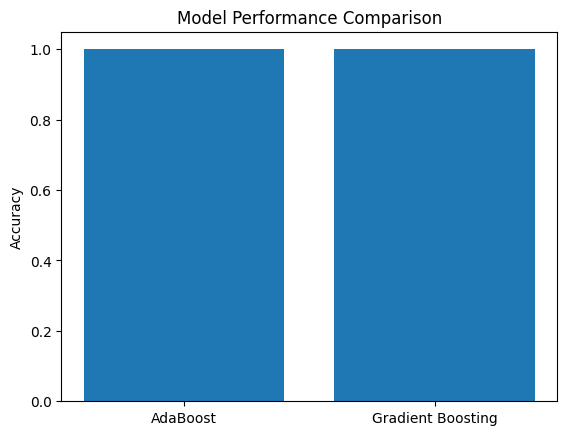

In [10]:
models = ["AdaBoost", "Gradient Boosting"]
accuracies = [ada_acc, gb_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Performance Comparison")
plt.ylabel("Accuracy")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


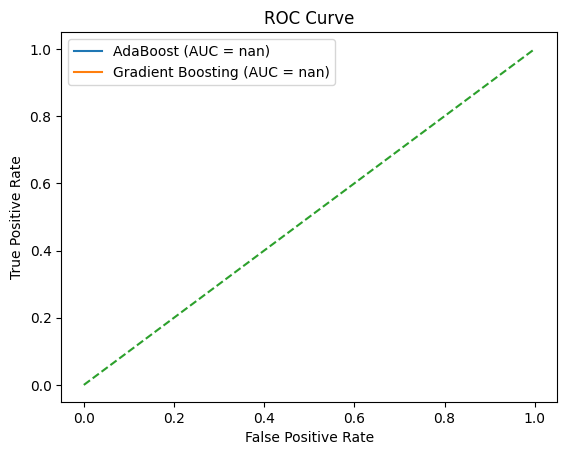

In [11]:
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

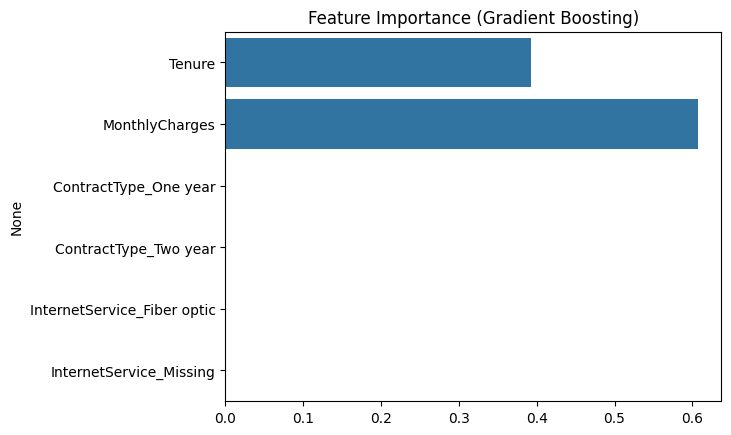

In [12]:
importances = gb.feature_importances_
features = X.columns

plt.figure()
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Gradient Boosting)")
plt.show()